In [1]:
import slideio
from utils import get_driver_test_images, display_driver_test_image_info, \
                    extract_image_properties, show_scenes, show_images
import matplotlib.pyplot as plt
import json

In [2]:
slideio.get_version()

'2.8.1'

# Test images
For the future demonstration of the library, we will be utilizing some test images. Information regarding the images and the drivers required for image processing is stored in the *image.json* file. The helper utility *get_test_images* loads this image information into a list for convenient access and utilization during the demonstration.

In [3]:
driver_id = 'OMETIFF'

In [4]:
images = get_driver_test_images(driver_id)
display_driver_test_image_info(images, driver_id)

Image Path,Driver
./images/4D-series.ome.tiff,OMETIFF


In [5]:
slide = slideio.open_slide(images[0]['path'], driver_id)
extract_image_properties(images)

,Path,Scene index,Num Channels,Data Type,Compression,Width,Height,Z Slices,Z Frames,Num zoom levels
0,./images/4D-series.ome.tiff,0,1,int8,Uncompressed,439,167,5,7,1 ()


Number of scenes: 1


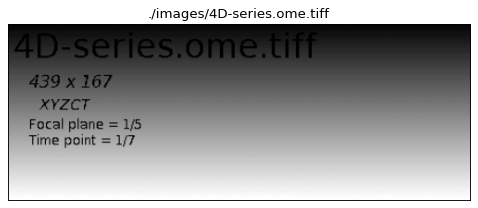

In [7]:
scenes = []
for image in images:
    slide = slideio.open_slide(image['path'], driver_id)
    num_scenes = slide.num_scenes
    for sc in range (0, num_scenes):
        scenes.append(slide.get_scene(sc))
show_scenes(scenes, 2, (500,500))

# Multidimensional images
VSI driver supports 3D images and time series. The code snipet below extracts Z slices for a 4D stack.

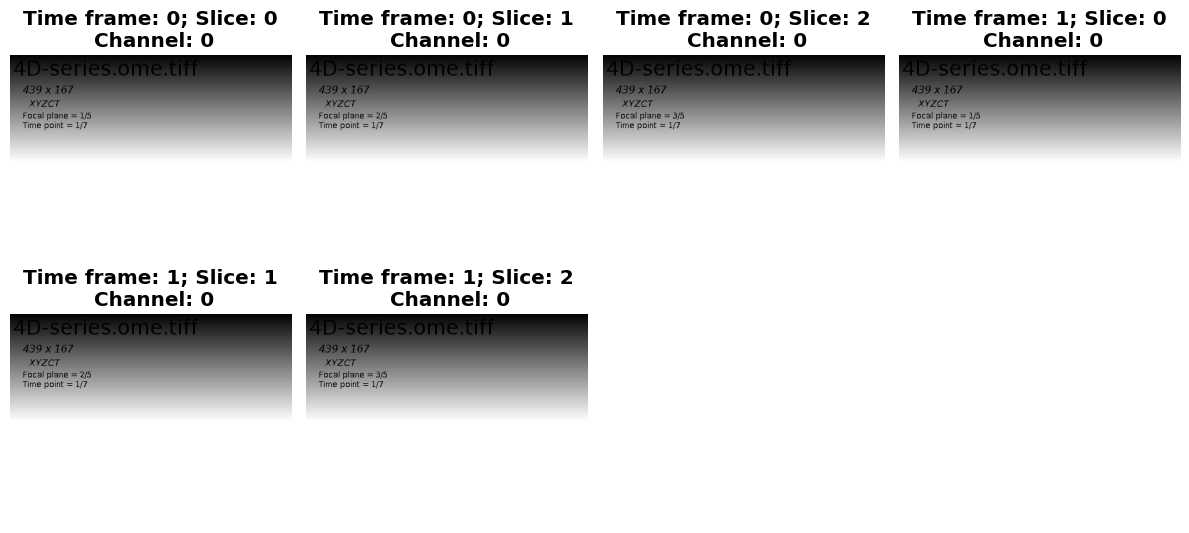

In [12]:
slide = slideio.open_slide(images[0]['path'], driver_id)
scene = slide.get_scene(0)
num_slices = scene.num_z_slices
num_time_frames = scene.num_t_frames
slices = []
titles = []
num_time_frames = min(2, num_time_frames)
num_slices = min(3, num_slices)
for time_frame in range (num_time_frames):
    for slice_index in range (num_slices):
        for channel_index in range (scene.num_channels):
            slice = scene.read_block(channel_indices=[channel_index], slices=(slice_index, slice_index+1)) 
            title = f"Time frame: {time_frame}; Slice: {slice_index}\n Channel: {channel_index}"
            titles.append(title)
            slices.append(slice)
show_images(slices, titles, 300, 4)

# Metadata¶
Slide object produced by the driver exposes metadata in XML format.

In [18]:
slide = slideio.open_slide(images[0]['path'], driver_id)
mtd = slide.raw_metadata
mtd_form = slide.metadata_format
mtd_form

<MetadataFormat.XML: 4>

### The raw_metadata contains a string with original OME-TIFF xml

In [23]:
import xml.etree.ElementTree as ET
root = ET.fromstring(mtd)
root

<Element '{http://www.openmicroscopy.org/Schemas/OME/2016-06}OME' at 0x000002783F05C180>

### Property `metadata` contains a dictionary constructed from the OME-TIFF xml

In [31]:
from pprint import pprint
pprint(slide.metadata, depth=3)

{'OME': {'@Creator': 'OME Bio-Formats 5.2.2',
         '@UUID': 'urn:uuid:c8a261cc-6798-4e58-885a-dcee460619f9',
         '@xmlns': 'http://www.openmicroscopy.org/Schemas/OME/2016-06',
         '@xmlns:xsi': 'http://www.w3.org/2001/XMLSchema-instance',
         '@xsi:schemaLocation': 'http://www.openmicroscopy.org/Schemas/OME/2016-06 '
                                'http://www.openmicroscopy.org/Schemas/OME/2016-06/ome.xsd',
         'Image': {'@ID': 'Image:0',
                   '@Name': '4D-series.ome.tiff',
                   'Pixels': {...}}}}
